# Recap


In [3]:
import numpy as np
import matplotlib.pyplot as plt

## Recap en uitbreiding

Je hebt al gezien hoe je een botsend deeltjesmodel maakt. Je startte toen met 1 of 2 deeltjes en hebt dit uitgebreid naar ~100 deeltjes. Daarbij was het logisch om gebruik te maken van classes.

Voor het maken van een simulatie van gasmoleculen in een gesloten volume zal je logischerwijs de volgende stappen doorlopen:
1. bepalen van initiële condities
2. definiëren van de deeltjes
3. definiëren van volume met randvoorwaarden
4. simulaties bestaande uit:
    - bepaling van positie van deeltjes
    - controleren op onderlinge botsingen 
    - controleren op botsingen met wanden
    - aanpassen van eigenschappen zoals totaal volume of temperatuur
    - opslaan van gegevens
    
```{note}
Alhoewel het interessant is om steeds een animatie te maken van de beweging van de deeltjes, vraagt dit veel rekentijd. Je kan ook regelmatig een plot maken om te controleren of het programma werkt zoals je verwacht.
```

### De initiële condities

In onze simulatie gaan we uit van een aantal aannames. Bij deze aannames wil je dat de simulatie een voorspellende waarde heeft voor een reëel systeem, maar ook dat de benodigde rekenkracht voor het uitvoeren van de simulatie op te brengen is. We kiezen daarom voor de volgende condities:

- Ons model heeft een beperkt en constant aantal deeltjes.
- We maken gebruik van een 2D simulatie.
- De deeltjes voelen geen onderlinge kracht en ondergaan alleen elastische botsingen.
- (tijdens simuleren) De tijdstap is voldoende klein. (d.w.z. de afgelegde weg $v_0*dt$ is klein in vergelijking met de diameter van de deeltjes, zodat we geen botsingen missen)

Hieronder geven we een aantal constanten voor onze code. Om de simulatie straks te kunnen interpreteren, vergelijken we deze eerst met een realistische situatie:

```{exercise} Lucht in een fietsband
:label: ex-recap-1

Als model gaan we uit van een deel van het volume van een fietsband die onder een druk van 10 bar staat. Schat hiervoor het gemiddelde volume $V_{molecuul}$. Het antwoord gebruik je zo direct in de code hieronder. 
```

```{solution} ex-recap-1
Jouw antwoord
```

De simulatie die we gaan maken bevat maar twee dimensies. We kunnen het oppervlak per deeltje in deze simulatie daarom kiezen als het zojuist berekende $V_{molecuul}^{2/3}$.

Voor de gemiddelde snelheid, $v$, van een molecuul geldt dat

$$
    \frac{1}{2}m\left< v^2\right> = \frac{f}{2} k_B T.
$$

Hierbij is $m$ de massa van het deeltje, $f$ het aantal dimensies, $k_B$ de constante van Boltzmann en $T$ de temperatuur.

```{exercise} Snelheid van een gasmolecuul
:label: ex-recap-2
Schat de snelheid van een gasmolecuul bij kamertemperatuur in twee dimensies. Ook deze heb je hierna nodig.
```

```{solution} ex-recap-2
Jouw antwoord
```

```{exercise} Radius
:label: ex-recap-3
Kies de eenheden waarin je de simulatie wilt gaan uitwerken. Dit kan in $\mathrm{m}$ maar ook in $\mathrm{mm}$ of iets anders. Pas de waardes voor de constanten `BOX_SIZE_0` en `V_0` in de hieronder gegeven code aan, zodat de simulatie een redelijk tweedimensionaal model is voor de fietsband. Hou hierbij het aantal deeltjes $N=40$ om de rekentijd van het model te beperken. Kies `RADIUS` gelijk aan 0.3 nm gebruik makend van jouw eenhedenstelsel.
```

```{solution} ex-recap-3
Jouw antwoord
```

```{exercise} DT
:label: ex-recap-4
Pas waarde van `DT` aan zodat de verplaatsing van een deeltje in een tijdstap klein genoeg is om te detecteren of deze met een ander deeltje botst. Zet in het groene commentaar bij elke constante in welk eenheid deze wordt weergegeven.
```

Onze simulatie modelleert dus een klein systeem zonder rekening te houden met de kracht tussen de luchtmoleculen. Je zult zien dat we toch al behoorlijk wat van de processor vragen om deze berekeningen te doen. Om een meer realistische modelsimulatie te maken is daarom een serieuze uitdaging, die veel wiskunde en programmeerervaring vraagt. Op dit ogenblik wordt dit bijvoorbeeld gevraagd bij een van de eerste opdrachten van het vak 'Computational Physics' van de master Applied Physics. 

In [4]:
# Berekening van het gemiddelde volume per molecuul bij 10 bar

k_B = 1.380649e-23     # [J/K] Boltzmannconstante
T = 300                # [K]    kamertemperatuur
P = 10 * 1e5           # [Pa]   druk van 10 bar

V_molecuul = (k_B * T) / P   # [m^3] gemiddeld volume per molecuul


V_molecuul
print(f"geschatte Gemiddeld volume per molecuul: {V_molecuul:.3e} m^3")


geschatte Gemiddeld volume per molecuul: 4.142e-27 m^3


In [5]:
#opdracht 2: 
# Constanten
k_B = 1.380649e-23        # Boltzmann-constante (J/K)
T = 293                   # Temperatuur (K)
m = 4.8e-26               # Massa van N2-molecuul (kg)
f = 2                     # aantal dimensies (2D)

# Berekening <v^2> voor 2D
v_squared = (f * k_B * T) / m

# Gemiddelde snelheid
v = np.sqrt(v_squared)

print(f"Gemiddelde snelheid van een gasmolecuul in 2D bij 293 K: {v:.2f} m/s")


Gemiddelde snelheid van een gasmolecuul in 2D bij 293 K: 410.55 m/s


In [ ]:
#opdracht 3:

# Afgeleide 2D-oppervlakte per deeltje
area_per_particle = V_molecuul ** (2.0/3.0)   # m^2

# Simulator parameters
N = 40                                     # aantal deeltjes (gegeven)
packing_factor = 10                        # >1 maakt de box ruimer dan minimale packing
BOX_SIZE_0 = np.sqrt(N * area_per_particle * packing_factor)  # box-side (m)

# Deeltjes-parameters
RADIUS = 0.3e-9        # 0.3 nm in meters
MASS = 4.8e-26         # massa N2 (kg), voorbeeld
# Gemiddelde snelheid in 2D bij T=300 K: v = sqrt( (f * k_B * T) / m ) met f=2
k_B = 1.380649e-23
T = 300.0
f = 2
V_0 = np.sqrt((f * k_B * T) / MASS)   # m/s ≈ 4.16e2 m/s

# Tijdstap: kies klein genoeg dat v * dt << diameter (2*RADIUS)
DT = 1e-12   # s

# Simulatie-instellingen
STEPS = 3000

print("Instellingen:")
print(f" BOX_SIZE_0 = {BOX_SIZE_0:.3e} m")
print(f" area_per_particle = {area_per_particle:.3e} m^2")
print(f" RADIUS = {RADIUS:.3e} m")
print(f" V_0 = {V_0:.3e} m/s")
print(f" DT = {DT:.3e} s")
print(f" NOTE: diameter = {2*RADIUS:.3e} m, v0*DT = {V_0*DT:.3e} m")


class Particle:
    def _init_(self, x, y, vx, vy, radius, mass):
        self.x = x
        self.y = y
        self.vx = vx
        self.vy = vy
        self.radius = radius
        self.mass = mass

    def update_position(self, dt):
        self.x += self.vx * dt
        self.y += self.vy * dt

    def wall_collision(self, L):
        # reflectie met behoud van snelheidsgrootte (elastisch)
        if self.x - self.radius < 0:
            self.x = self.radius
            self.vx *= -1
        if self.x + self.radius > L:
            self.x = L - self.radius
            self.vx *= -1
        if self.y - self.radius < 0:
            self.y = self.radius
            self.vy *= -1
        if self.y + self.radius > L:
            self.y = L - self.radius
            self.vy *= -1

def particle_collision(p1, p2):
    dx = p2.x - p1.x
    dy = p2.y - p1.y
    dist2 = dx*dx + dy*dy
    min_dist = p1.radius + p2.radius

    if dist2 < min_dist**2 and dist2 > 0:
        dist = np.sqrt(dist2)
        # normaalvector
        nx = dx / dist
        ny = dy / dist

        # relatieve snelheid langs normaal
        dvx = p1.vx - p2.vx
        dvy = p1.vy - p2.vy
        rel_norm = dvx * nx + dvy * ny

        if rel_norm < 0:  # alleen als ze naar elkaar toe bewegen
            # elastische botsing (1D langs normaal)
            # voor ongelijke massa: conserveer impuls en energie
            m1, m2 = p1.mass, p2.mass
            # impuls uitwisseling langs normaal
            J = (2 * m1 * m2 * rel_norm) / ((m1 + m2))
            # update snelheden
            p1.vx -= (J / m1) * nx
            p1.vy -= (J / m1) * ny
            p2.vx += (J / m2) * nx
            p2.vy += (J / m2) * ny

            # simpele overlap-correctie: schuif ze net buiten elkaar
            overlap = min_dist - dist
            shift1 = overlap * (m2 / (m1 + m2))
            shift2 = overlap * (m1 / (m1 + m2))
            p1.x -= nx * shift1
            p1.y -= ny * shift1
            p2.x += nx * shift2
            p2.y += ny * shift2

# INITIALISATIE

particles = []
rng = np.random.default_rng(seed=42)

for _ in range(N):
    # eenvoudige positie-init: uniform binnen box, (kan overlappen veroorzaken bij zeer kleine boxes).
    x = rng.uniform(RADIUS, BOX_SIZE_0 - RADIUS)
    y = rng.uniform(RADIUS, BOX_SIZE_0 - RADIUS)
    angle = rng.uniform(0, 2*np.pi)
    vx = V_0 * np.cos(angle)
    vy = V_0 * np.sin(angle)
    particles.append(Particle(x, y, vx, vy, RADIUS, MASS))



# SIMULATIELOOP

STEPS = 2000

for step in range(STEPS):

    # update posities
    for p in particles:
        p.update_position(DT)
        p.wall_collision(BOX_SIZE_0)

    # botsingen tussen deeltjes
    for i in range(N):
        for j in range(i+1, N):
            particle_collision(particles[i], particles[j])

    # af en toe visualiseren
    if step % 200 == 0:
        xs = [p.x for p in particles]
        ys = [p.y for p in particles]
        plt.clf()
        plt.scatter(xs, ys, s=10)
        plt.xlim(0, BOX_SIZE_0)
        plt.ylim(0, BOX_SIZE_0)
        plt.title(f"Simulatie stap {step}")
        plt.pause(0.01)

Instellingen:
 BOX_SIZE_0 = 3.211e-08 m
 area_per_particle = 2.578e-18 m^2
 RADIUS = 3.000e-10 m
 V_0 = 4.154e+02 m/s
 DT = 1.000e-12 s
 NOTE: diameter = 6.000e-10 m, v0*DT = 4.154e-10 m


NameError: name 'Particle' is not defined

### Particle class
Onze `ParticleClass` definieert van een deeltje de massa $m$, snelheid $v$, positie $r$, en straal $R$. De positie moet per tijdstap bepaald worden. 

Nieuw aan `ParticleClass` zijn twee properties, nl. `momentum` en `energy`. Een property is eigenlijk een variabele die samenhangt met de waarde van andere variabelen binnen de klasse. Om de interne consistentie te bewaren moet je de juiste waarde van deze variabele dus telkens afleiden en dat doe je met een functie. Zo geeft `kin_energy` de kinetische energie terug van het deeltje door die af te leiden van de variabelen `m` en `v`.

Buiten `ParticleClass` voegen we twee functies toe, die je ook al hebt gezien. De eerste heet `collide_detection` en detecteert of twee deeltjes onderling overlappen en dus botsen. De tweede heet `particle_collision` en berekent de nieuwe snelheden van de twee deeltjes ten gevolge van hun botsing.

In [5]:
# Maken van de class
class ParticleClass:
    def __init__(self, m, v, r, R):
        """ maakt een deeltje (constructor) """
        self.m = m                         
        self.v = np.array(v, dtype=float)  
        self.r = np.array(r, dtype=float)  
        self.R = R

    def update_position(self):
        """ verandert positie voor één tijdstap """
        self.r += self.v * DT 
            
    @property
    def momentum(self):
        return self.m * self.v
    
    @property
    def kin_energy(self):
        return 1/2 * self.m * np.dot(self.v, self.v)
    
def collide_detection(p1: ParticleClass, p2: ParticleClass) -> bool:
    """ Geeft TRUE als de deeltjes overlappen """
    """ Geeft TRUE als de deeltjes overlappen """
    dx = p1.r[0]-p2.r[0]
    dy = p1.r[1]-p2.r[1]
    rr = p1.R + p2.R
    return  dx**2+dy**2 < rr**2 
    #Note: np.linalg.norm(p1.r - p2.r) < (p1.R + p2.R) had ook gekund, maar is veel langzamer. Controleer zelf!

def particle_collision(p1: ParticleClass, p2: ParticleClass):
    """ past snelheden aan uitgaande van overlap """
    m1, m2 = p1.m, p2.m
    delta_r = p1.r - p2.r
    delta_v = p1.v - p2.v
    dot_product = np.dot(delta_r, delta_v)
    
    # Als deeltjes van elkaar weg bewegen dan geen botsing
    if dot_product >= 0: # '='-teken voorkomt ook problemen als delta_r == \vec{0}
        return
        
    distance_squared = np.dot(delta_r, delta_r) 
    # Botsing oplossen volgens elastische botsing in 2D
    p1.v -= 2 * m2 / (m1 + m2) * dot_product / distance_squared * delta_r
    p2.v += 2 * m1 / (m1 + m2) * dot_product / distance_squared * delta_r

### Volume en randvoorwaarden

Voor het volume maken we gebruik van het oppervlak van een `pyplot`, net zoals we dat in Q1 gedaan hebben. Daar is op dit ogenblik niets anders voor nodig dan een functie die de deeltjes laat botsen met de wanden.

Je hebt hiervoor al een voorbeeld van gezien, maar hieronder gebruiken we een andere vorm. Als je code ontwikkelt is het zaak om regelmatig en structureel te controleren of je code klopt. Het maakt daarbij niet uit of de code door jezelf is gemaakt, door een ander (zoals de docent) is aangeboden of van een generatieve AI komt. Hoe langer je code toevoegt zonder een controle uit te voeren, hoe groter de kans is dat je fout op fout stapelt en niet meer kan traceren wat er precies mis is. 

We maken gebruik van een truc die in veel simulaties wordt gebruikt: we maken gebruik van periodieke randvoorwaarden. In dit geval wil dit zeggen dat een deeltje dat botst met de wand aan de ene kant van het volume, aan de andere kant verschijnt met exact dezelfde snelheid. Op deze manier verandert de snelheid van een deeltje niet bij het botsen met de wand en blijven alle behoudswetten gelden. Die behoudswetten kunnen we straks goed controleren.

In [6]:
def box_collision(particle: ParticleClass):
    ''' botsing met wanden geeft periodieke randvoorwaarden '''
    for i in range(2):
        if particle.r[i] > BOX_SIZE_0 / 2:
            particle.r[i] -= BOX_SIZE_0 
        elif particle.r[i] < -BOX_SIZE_0 / 2:
            particle.r[i] += BOX_SIZE_0

### Maken van de simulatie

Nu dat we alle benodigde functies hebben, kunnen we ze in de juiste structuur zetten om de simulatie uit te voeren.

#### Bepaling positie deeltjes

Eerst moeten we alle deeltjes aanmaken en de startwaardes van hun variabelen invoeren:


```{exercise}
:label: const_speed
Leg uit dat d.m.v. onderstaande code de deeltjes allemaal dezelfde snelheid hebben en uniform verdeeld zijn over de box.
```

```{solution} const_speed
Jouw antwoord hier...
```

In [7]:
def create_particles(particles):
    ''' Leegmaken en opnieuw aanmaken van deeltjes '''
    particles.clear()
    for i in range(N):
        # genereer vx willekeurig in [-V_0, V_0] en bereken vy zo dat |v| ~= V_0
        vx = np.random.uniform(-V_0, V_0)
        # bescherm tegen kleine afrondfouten met max(..., 0)
        vy = np.random.choice([-1, 1]) * np.sqrt(max(V_0**2 - vx**2, 0.0))
        pos = np.random.uniform(-BOX_SIZE_0/2 + RADIUS, BOX_SIZE_0/2 - RADIUS, 2)
        particles.append(ParticleClass(m=1.0, v=[vx, vy], r=pos, R=RADIUS))

#### Controleren op onderlinge botsingen

Om de botsingen van alle deeltjes goed te verwerken moeten we controleren welke paren deeltjes met elkaar moeten botsen en deze botsingen één keer uitvoeren. 

```{exercise}
:label: double_loop
Leg uit hoe er in onderstaande code wordt voorkomen dat de botsing tussen twee deeltjes dubbel wordt uitgevoerd.
```

```{solution} double_loop
Jouw antwoord hier...
```

In [8]:
def handle_collisions(particles):
    """ alle onderlinge botsingen afhandelen voor deeltjes in lijst """
    num_particles = len(particles)
    for i in range(num_particles):
        for j in range(i+1, num_particles):
            if collide_detection(particles[i], particles[j]):
                particle_collision(particles[i], particles[j])

#### Controleren op botsingen met wanden

Voor het bepalen of deeltjes botsen met de wanden maken we gebruik van de functie die we net hebben aangepast.

In [9]:
def handle_walls(particles):
    ''' botsing met wanden controleren voor alle deeltjes in volume '''
    for p in particles:
        box_collision(p)

#### Integreren in tijdstap

Nu moeten we alle functies op de juiste manier combineren om de simulatie een tijdstap te laten maken:

In [10]:
def take_time_step(particles):
    for p in particles:
        p.update_position()
        
    handle_collisions(particles)
    handle_walls(particles)  


### Uitvoeren simulatie en tonen resultaat

Zoals aangegeven, kunnen we een animatie maken van de positie en snelheid als functie van de tijd, maar we kunnen ook het eindresultaat tonen en interpreteren:

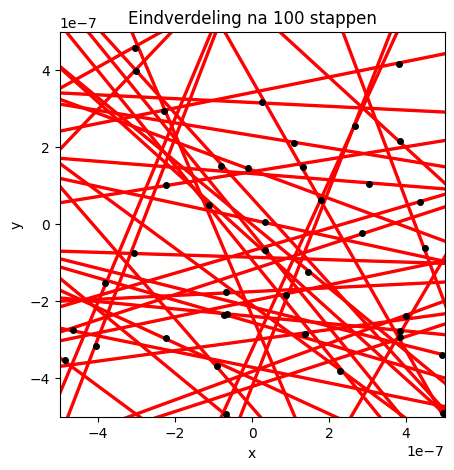

In [11]:
# Uitvoeren simulatie en tonen resultaat; we registreren tevens totale kinetische energie en momentum
particles = []
create_particles(particles)

n_steps = 100
total_ke = []
total_momentum = []

for i in range(n_steps):
    take_time_step(particles)
    # totale kinetische energie
    ke = sum(p.kin_energy for p in particles)
    total_ke.append(ke)
    # totale momentum-vector en scalaire norm
    mom = np.sum([p.momentum for p in particles], axis=0)
    total_momentum.append(np.linalg.norm(mom))

plt.figure(figsize=(5,5))
plt.xlabel('x')
plt.ylabel('y')
plt.gca().set_aspect('equal')
plt.xlim(-BOX_SIZE_0/2, BOX_SIZE_0/2)
plt.ylim(-BOX_SIZE_0/2, BOX_SIZE_0/2)

for p in particles:
    plt.plot(p.r[0], p.r[1], 'k.', ms=8)
    plt.arrow(p.r[0], p.r[1], p.v[0]*DT*10, p.v[1]*DT*10, 
              head_width=RADIUS*5, head_length=RADIUS*5, color='red')
plt.title('Eindverdeling na {} stappen'.format(n_steps))
plt.show()

### Toevoegen animatie

Zoals gezegd: het kost veel meer rekenkracht om een animatie te maken over de tijd. Soms kan het wel helpen om te zien of de simulatie aan alle verwachtingen voldoet. 

In [12]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, ax = plt.subplots()
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_xlim(-BOX_SIZE_0/2, BOX_SIZE_0/2)
ax.set_ylim(-BOX_SIZE_0/2, BOX_SIZE_0/2)
ax.set_aspect('equal')

# gebruik scatter voor meerdere deeltjes
scat = ax.scatter([], [], c='k', s=30)

def init():
    scat.set_offsets(np.empty((0,2)))
    return scat,

def update(frame):
    take_time_step(particles)
    coords = np.array([p.r for p in particles])
    scat.set_offsets(coords)
    return scat,

ani = FuncAnimation(fig, update, frames=100, init_func=init, blit=True, interval=50)
plt.close(fig)
HTML(ani.to_jshtml())

### Controle code

Om te controleren of onze code werkt passen we nu de code aan.

```{exercise}
Voeg aan de simulatie een regel toe die voor elke tijdstap bepaalt wat de totale kinetische energie is voor alle deeltjes en neem deze waarde op in een array die bij elke tijdstap met één element groeit in lengte. Maak een plot van de totale kinetische energie als functie van de tijd gedurende een simulatie van 100 tijdstappen.
```

```{exercise}
:label: ex-recap-6

Maak een plot van de totale kinetische energie als functie van de tijd gedurende een simulatie van 100 tijdstappen.
```

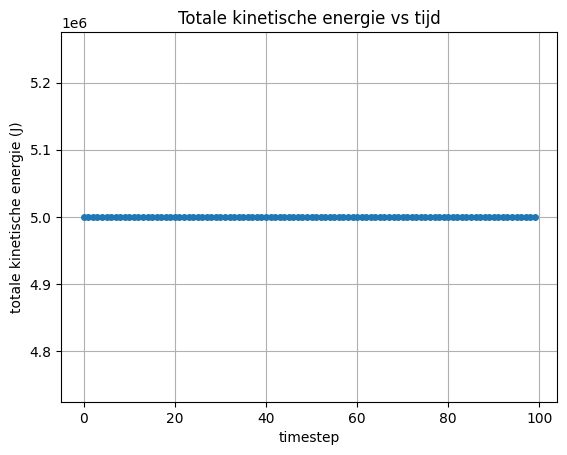

In [13]:
# Plot van totale kinetische energie als functie van de tijd
plt.figure()
plt.plot(range(len(total_ke)), total_ke, '-o', markersize=4)
plt.xlabel('timestep')
plt.ylabel('totale kinetische energie (J)')
plt.title('Totale kinetische energie vs tijd')
plt.grid(True)
plt.show()

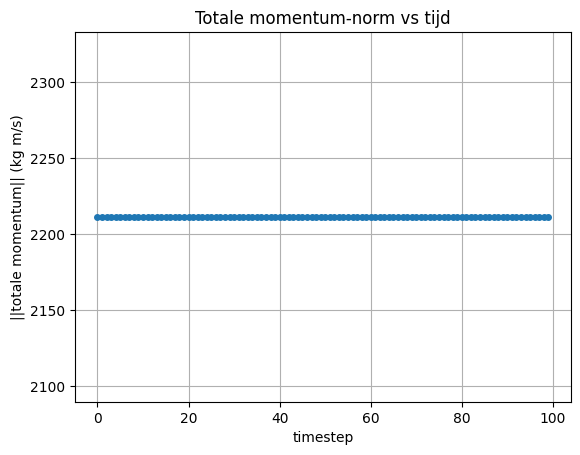

In [14]:
# Plot totale momentum-norm als functie van de tijd
plt.figure()
plt.plot(range(len(total_momentum)), total_momentum, '-o', markersize=4)
plt.xlabel('timestep')
plt.ylabel('||totale momentum|| (kg m/s)')
plt.title('Totale momentum-norm vs tijd')
plt.grid(True)
plt.show()

```{exercise} 
:label: error_energy
Als je heel nauwkeurig naar de waarde voor de totale kinetische energie kijkt, dan varieert deze toch. Zoom hiervoor goed in op de as voor de energie. Op welke energieschaal gebeurt dit en is de oorzaak?
```

```{solution} error_energy
Jouw antwoord hier...
```

```{exercise}
:label: more_error
Noem nog een andere grootheid die behouden moet zijn. Geef ook van deze grootheid een plot van de waarde gedurende 100 tijdstappen. Zoom ook hier goed in. Is hier een variatie en zo ja, waardoor?
```



In [15]:
# Extra check: gemiddelde kinetische energie en vergelijk met beginwaarde
print('begin totale KE (approx):', total_ke[0])
print('eind totale KE:', total_ke[-1])
print('relatieve verandering KE:', (total_ke[-1]-total_ke[0])/total_ke[0])

begin totale KE (approx): 5000000.0
eind totale KE: 5000000.0
relatieve verandering KE: 0.0


```{exercise}
Laat je werk aftekenen door een TA
```